# NLP Milestone 2    |    Group 12

## Overview
This notebook documents the data preprocessing and exploratory analysis pipeline for the TL;DR summarization dataset used in our project.

The goal is to transform the raw Reddit data into a clean, structured format suitable for supervised fine-tuning and preference-aligned training (e.g., DPO).
The notebook performs the following main steps:

- Load and inspect the original dataset from Hugging Face (trl-lib/tldr).

- Parse and normalize each post into structured fields (subreddit, title, post_body, gold_tldr, etc.).

- Clean and standardize text content, including demographic tag normalization and de-duplication.

- Generate descriptive statistics and visualizations to analyze post length, summary length, compression ratio, and topic distribution.

- Save the processed dataset (tldr_cleaned/) for downstream fine-tuning and evaluation.

In [1]:
from datasets import load_dataset, load_from_disk,Dataset, DatasetDict
import os, re, hashlib
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# load and show dataset
raw = load_dataset("trl-lib/tldr")
for split in raw:
    print(split, len(raw[split]))


train 116722
validation 6447
test 6553


In [3]:
# Patterns for extracting structure

HDR_SUB = re.compile(r'^\s*SUBREDDIT\s*:\s*(.+)$', re.I | re.M)
HDR_TIT = re.compile(r'^\s*TITLE\s*:\s*(.+)$', re.I | re.M)
HDR_POST= re.compile(r'^\s*POST\s*:\s*(.*)$', re.I | re.M)
HDR_TLDR= re.compile(r'^\s*TL;?\s*DR\s*\s*:\s*$', re.I | re.M)  # TL;DR: or TLDR:

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
# Unicode emoji range
EMOJI_RE = re.compile(r'[\U00010000-\U0010ffff]', flags=re.UNICODE)
# Simple markdown/inline code emphasis markers
MD_RE    = re.compile(r'(\*{1,3}|_{1,3}|`{1,3})(.*?)\1')

In [4]:
# normolization and cleaning
def normalize_spaces(s: str) -> str:
    s = s.replace("\r", "\n")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    s = "\n".join(lines)
    return " ".join(s.split()).strip()

def clean_inline_noise(s: str) -> str:
    s = URL_RE.sub("[URL]", s)
    s = EMOJI_RE.sub("", s)
    s = MD_RE.sub(r"\2", s)
    return s

In [5]:
# Parsing function (extract subreddit / title / post / TL;DR)
def parse_prompt(prompt: str):
    t = prompt.replace("\r","\n")
    sub  = HDR_SUB.search(t).group(1).strip() if HDR_SUB.search(t) else "unknown"
    tit  = HDR_TIT.search(t).group(1).strip() if HDR_TIT.search(t) else "(none)"
    mpost= HDR_POST.search(t)
    mtldr= HDR_TLDR.search(t)
    start = mpost.end() if mpost else 0
    end   = mtldr.start() if mtldr else len(t)
    body  = t[start:end].strip()
    has_tldr = bool(mtldr)
    return sub, tit, body, has_tldr


In [6]:
# Normalize demographic tags: [F/22] → <GENDER_FEMALE> <AGE_22>
PATTERNS_DEMO = [
    re.compile(r'[\[(]{0,1}\s*(?P<g>[FfMm]|nb)\s*/\s*(?P<a>\d{1,2})\s*[\])]{0,1}'),
    re.compile(r'\b(?P<a>\d{1,2})(?:yo|y/?o|years?\s*old)?\s*(?P<g>[FfMm])\b'),
    re.compile(r'\b(?P<g>[FfMm])\s*(?P<a>\d{1,2})\b'),
]

def _norm_gender(g):
    g = (g or "").lower()
    return {"f":"FEMALE","m":"MALE","nb":"NONBINARY"}.get(g,"OTHER")

def normalize_demographics(text: str):
    def repl(m):
        g,a = m.group("g"), m.group("a")
        if not a or not a.isdigit(): return m.group(0)
        age = int(a)
        if 10 <= age <= 99:
            return f"<GENDER_{_norm_gender(g)}> <AGE_{age}>"
        return m.group(0)
    out = text
    for p in PATTERNS_DEMO:
        out = p.sub(repl, out)
    return out


In [7]:
# Sentence-level extraction (length control)
def sentence_split(s: str):
    s = s.replace("\r","\n")
    chunks = re.split(r'(?<=[^.0-9][.?!])\s+|\n+', s)
    return [c.strip() for c in chunks if c.strip()]

def select_key_sentences(body: str, max_words: int = 1024):
    sents = sentence_split(body)
    if not sents: return body
    pick = [sents[0]] + sents[-1:]
    
    # Add supplementary sentences containing numbers, time, or questions
    for s in sents[1:-1]:
        if re.search(r'\d|[?]|today|year|week|month', s, re.I):
            pick.append(s)
    out = " ".join(pick)
    words = out.split()
    return " ".join(words[:max_words])


In [8]:

def build_record(ex):
    sub, tit, body, has_tldr = parse_prompt(ex["prompt"])
    sub, tit = sub.strip(), normalize_spaces(tit)
    body = clean_inline_noise(normalize_spaces(body))
    tldr = clean_inline_noise(normalize_spaces(ex["completion"]))
    body_demo = normalize_demographics(body)
    body_sel = select_key_sentences(body_demo)

    post_for_model = f"SUBREDDIT: {sub}\nTITLE: {tit}\nPOST:\n{body_sel}\n\nTL;DR:"
    post_plain = f"SUBREDDIT: {sub}\nTITLE: {tit}\nPOST:\n{body}"

    return {
        "subreddit": sub,
        "title": tit,
        "post_body": body,
        "post_for_model": post_for_model,
        "post_plain": post_plain,
        "gold_tldr": tldr,
        "has_tldr_token": has_tldr,
        "len_post_words": len(body.split()),
        "len_tldr_words": len(tldr.split()),
        "hash": hashlib.sha1(post_plain.encode()).hexdigest()
    }


In [9]:
# Cleaning + filtering + deduplication
def clean_dataset(raw_split):
    records = []
    for ex in tqdm(raw_split, desc="processing"):
        r = build_record(ex)
        if 30 <= r["len_post_words"] <= 5000 and 6 <= r["len_tldr_words"] <= 80:
            records.append(r)
    ds = Dataset.from_list(records)
    df = ds.to_pandas()
    df = df.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)
    return Dataset.from_pandas(df, preserve_index=False)


In [12]:
# Run preprocessing and descriptive statistics
train = clean_dataset(raw["train"])
val   = clean_dataset(raw["validation"])
test  = clean_dataset(raw["test"])

print("Train:", len(train), "Val:", len(val), "Test:", len(test))

def show_stats(ds, name):
    lp, lt = np.array(ds["len_post_words"]), np.array(ds["len_tldr_words"])
    print(f"[{name}] mean_post={lp.mean():.1f}, mean_tldr={lt.mean():.1f}, compression={lt.mean()/lp.mean():.3f}")

for name, ds in [("train", train), ("val", val), ("test", test)]:
    show_stats(ds, name)


processing: 100%|██████████| 6553/6553 [00:01<00:00, 4793.06it/s]


Train: 99929 Val: 5570 Test: 5577
[train] mean_post=201.4, mean_tldr=27.1, compression=0.135
[val] mean_post=200.7, mean_tldr=27.1, compression=0.135
[test] mean_post=203.2, mean_tldr=27.2, compression=0.134


In [13]:
# save cleaned dataset
cleaned = DatasetDict({
    "train": train,
    "validation": val,
    "test": test
})

os.makedirs("data/tldr_cleaned", exist_ok=True)
cleaned.save_to_disk("data/tldr_cleaned")
print(" Saved to data/tldr_cleaned")


Saving the dataset (0/1 shards):   0%|          | 0/99929 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5570 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5577 [00:00<?, ? examples/s]

 Saved to data/tldr_cleaned


In [14]:
# show saved dataset
from datasets import load_from_disk

ds = load_from_disk("data/tldr_cleaned")
# print(ds)

sample = ds["train"][0]
print(sample)
# for key, value in sample.items():
#     print(f"\n--- {key.upper()} ---\n{value}")
#     break


{'subreddit': 'r/relationships', 'title': 'I (f/22) have to figure out if I want to still know these girls or not and would hate to sound insulting', 'post_body': "Backstory: When I (f/22) went through my first real breakup 2 years ago because he needed space after a year of dating roand it effected me more than I thought. It was a horrible time in my life due to living with my mother and finally having the chance to cut her out of my life. I can admit because of it was an emotional wreck and this guy was stable and didn't know how to deal with me. We ended by him avoiding for a month or so after going to a festival with my friends. When I think back I wish he just ended. So after he ended it added my depression I suffered but my friends helped me through it and I got rid of everything from him along with cutting contact. Now: Its been almost 3 years now and I've gotten better after counselling and mild anti depressants. My mother has been out of my life since then so there's been alot

## Dataset Structure
After preprocessing, the dataset was organized into three splits (train, validation, test) and each example contains ten features as described below.

| **Feature Name** | **Type**  | **Description**                                                                                                                                   | **Purpose / Usage**                                                                 |
| ---------------- | --------- | ------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| `subreddit`      | *string*  | Name of the subreddit from which the post originates (e.g., `r/relationships`, `r/AskReddit`).                                                    | Used for topic distribution analysis and potential domain adaptation.               |
| `title`          | *string*  | Original Reddit post title written by the user.                                                                                                   | Provides high-level topic context for summarization.                                |
| `post_body`      | *string*  | The full body text of the Reddit post after cleaning (URLs, emojis, and HTML removed).                                                            | Serves as the primary input text for summary generation.                            |
| `post_for_model` | *string*  | The structured input version used for model training, combining `SUBREDDIT`, `TITLE`, and `POST` with formatting and normalized demographic tags. | Direct model input for SFT / DPO training.                                          |
| `post_plain`     | *string*  | The plain post text without any added tokens (no “TL;DR” prompt).                                                                                 | Used for factuality or entailment evaluation (e.g., SummaC, QAFactEval).            |
| `gold_tldr`      | *string*  | The human-written TL;DR summary provided by the Reddit user.                                                                                      | Acts as the reference output (ground truth) for supervised training and evaluation. |
| `has_tldr_token` | *boolean* | Indicates whether a TL;DR tag was explicitly found in the original post.                                                                          | Helps identify posts with explicit summary cues.                                    |
| `len_post_words` | *int64*   | Word count of the cleaned post body.                                                                                                              | Used for descriptive statistics and filtering very short or long samples.           |
| `len_tldr_words` | *int64*   | Word count of the TL;DR summary.                                                                                                                  | Enables analysis of summary length distribution and compression ratio.              |
| `hash`           | *string*  | Unique hash identifier for each sample generated from the post text.                                                                              | Prevents duplicates and ensures dataset consistency across splits.                  |



## Data visulization

In [16]:
df = ds["train"].to_pandas()

df["compression_ratio"] = df["len_tldr_words"] / df["len_post_words"]

print(df.head(3))
print("\nTotal samples:", len(df))


         subreddit                                              title  \
0  r/relationships  I (f/22) have to figure out if I want to still...   
1         r/loseit                   SV & NSV! Keeping on keeping on.   
2  r/relationships  Me [19F] with my friend [19M] 10 months, Insec...   

                                           post_body  \
0  Backstory: When I (f/22) went through my first...   
1  I weigh myself weekly and measure myself month...   
2  I'm not currently in a relationship, but recen...   

                                      post_for_model  \
0  SUBREDDIT: r/relationships\nTITLE: I (f/22) ha...   
1  SUBREDDIT: r/loseit\nTITLE: SV & NSV! Keeping ...   
2  SUBREDDIT: r/relationships\nTITLE: Me [19F] wi...   

                                          post_plain  \
0  SUBREDDIT: r/relationships\nTITLE: I (f/22) ha...   
1  SUBREDDIT: r/loseit\nTITLE: SV & NSV! Keeping ...   
2  SUBREDDIT: r/relationships\nTITLE: Me [19F] wi...   

                                

In [17]:
print("Average post length (words):", df["len_post_words"].mean())
print("Average TL;DR length (words):", df["len_tldr_words"].mean())
print("Average compression ratio:", df["compression_ratio"].mean())

print("\nPost length range:", df["len_post_words"].min(), "–", df["len_post_words"].max())
print("TL;DR length range:", df["len_tldr_words"].min(), "–", df["len_tldr_words"].max())

print("\nNumber of unique subreddits:", df["subreddit"].nunique())


Average post length (words): 201.35547238539363
Average TL;DR length (words): 27.086541444425542
Average compression ratio: 0.1687356625685128

Post length range: 30 – 399
TL;DR length range: 7 – 47

Number of unique subreddits: 29


#### Distribution of Post Length

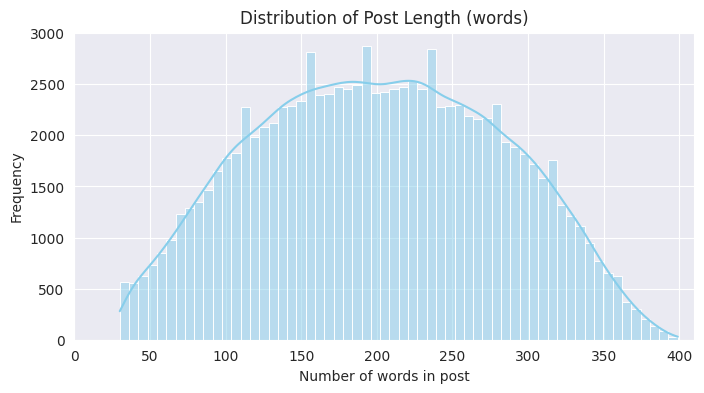

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df["len_post_words"], bins=60, color="skyblue", kde=True)
plt.title("Distribution of Post Length (words)")
plt.xlabel("Number of words in post")
plt.ylabel("Frequency")
plt.xlim(0, 410)
plt.show()


#### Distirbution of TL;DR Length

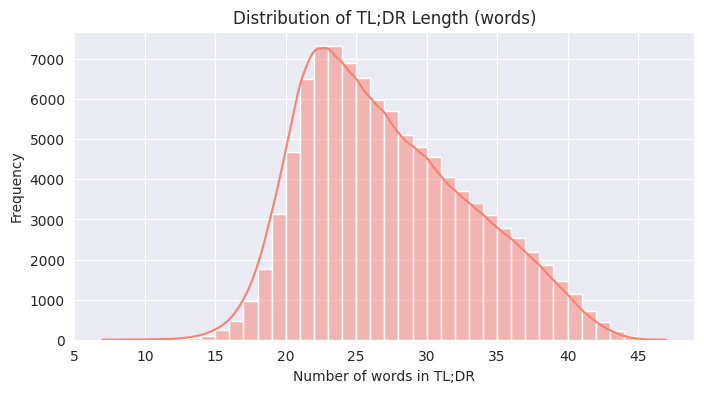

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df["len_tldr_words"], bins=40, color="salmon", kde=True)
plt.title("Distribution of TL;DR Length (words)")
plt.xlabel("Number of words in TL;DR")
plt.ylabel("Frequency")
plt.show()


#### Compression Ratio (TL;DR length / Post length)

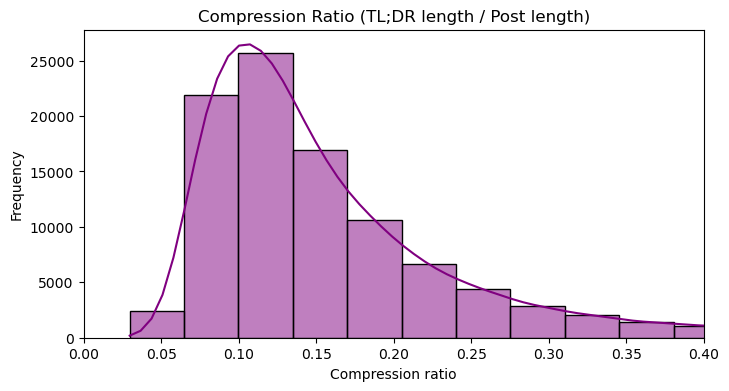

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["compression_ratio"], bins=40, color="purple", kde=True)
plt.title("Compression Ratio (TL;DR length / Post length)")
plt.xlabel("Compression ratio")
plt.ylabel("Frequency")
plt.xlim(0, 0.4)
plt.show()


#### Subreddits

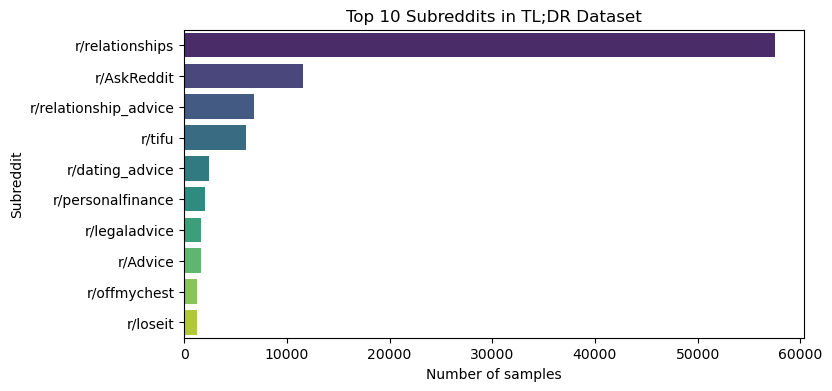

In [21]:
sub_counts = df["subreddit"].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=sub_counts.values,
    y=sub_counts.index,
    hue=sub_counts.index, 
    palette="viridis",
    legend=False           
)
plt.title("Top 10 Subreddits in TL;DR Dataset")
plt.xlabel("Number of samples")
plt.ylabel("Subreddit")
plt.show()


### Trian SFT

In [ ]:
import os
import numpy as np
import torch

from datasets import load_from_disk
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

# ==========================
# config
# ==========================
MODEL_NAME = "google/flan-t5-base"
DATA_DIR   = "data/tldr_cleaned"      
OUTPUT_DIR = "models/sft"

MAX_SOURCE_LEN = 512
MAX_TARGET_LEN = 128

LR = 5e-5
EPOCHS = 3
TRAIN_BS = 2
EVAL_BS = 2
GRAD_ACC = 4

rouge = evaluate.load("rouge")


def preprocess_function(examples, tokenizer):
    # source：post_for_model
    model_inputs = tokenizer(
        examples["post_for_model"],
        max_length=MAX_SOURCE_LEN,
        truncation=True,
    )
    # target：gold_tldr
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["gold_tldr"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
        )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


def compute_metrics(eval_pred, tokenizer):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    # decode
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # replace -100 in the labels as we can't decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    result = {k: round(v * 100, 2) for k, v in result.items()}
    return result


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 1. 模型 & tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

    # 2. 数据集
    dataset = load_from_disk(DATA_DIR)   # 需要包含 train / validation split
    column_names = dataset["train"].column_names

    tokenized = dataset.map(
        lambda batch: preprocess_function(batch, tokenizer),
        batched=True,
        remove_columns=column_names,
    )

    # 3. collator
    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        label_pad_token_id=-100,
    )

    # 4. training args
    bf16_flag = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    training_args = Seq2SeqTrainingArguments(
        output_dir=OUTPUT_DIR,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        gradient_accumulation_steps=GRAD_ACC,
        weight_decay=0.01,
        eval_strategy="steps",
        eval_steps=1000,
        save_strategy="steps",
        save_steps=1000,
        save_total_limit=3,
        load_best_model_at_end=True,
        predict_with_generate=True,
        generation_max_length=MAX_TARGET_LEN,
        bf16=bf16_flag,
        logging_steps=100,
        report_to=["tensorboard"],
        remove_unused_columns=False,
    )

    # 5. Trainer
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=lambda x: compute_metrics(x, tokenizer),
    )

    trainer.train()
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)


### Generate Candidates

In [ ]:
import os
import json
import torch
import argparse
from tqdm import tqdm
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import sys

# Import custom modules
sys.path.append(os.getcwd())
from src.decoding_utils import batch_generate

# ==============================================================================
# Configs
# ==============================================================================
MODELS_CONFIG = [
    # 1. SFT base (style: Reddit informal)
    ("sft", "models/sft"), 
    
    # 2. BART-CNN (style: long, detail-rich summaries)
    ("bart", "sshleifer/distilbart-cnn-12-6"),
    
    # 3. BART-XSum (style: very concise, highly abstract)
    ("bart_xsum", "facebook/bart-large-xsum")
]
# ==============================================================================

def get_signature(text):
    """
    Generate a text fingerprint: strip whitespace and take the first 100 chars.
    Must always generate signatures from the *same raw text* so IDs remain consistent.
    """
    if not text: return ""
    return text.strip()[:100]

def is_model_processed(responses_dict, model_name):
    """
    Check whether this model has already produced outputs.
    """
    prefix = f"{model_name}_"
    for k in responses_dict.keys():
        if k.startswith(prefix):
            return True
    return False

def load_model_safe(model_path, device):
    try:
        # Try standard load
        model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
    except Exception as e:
        print(f"  [Warn] Standard load failed, trying with weights_only=False... ({e})")
        # Force loading older weight formats (fixes torch.load errors)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_path, weights_only=False).to(device)
    return model

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_path", type=str, default="data/tldr_cleaned")
    parser.add_argument("--output_file", type=str, default="data/candidates/train_candidates_new.json")
    parser.add_argument("--max_samples", type=int, default=15000)
    parser.add_argument("--batch_size", type=int, default=4) 
    args = parser.parse_args()

    print("=== Step 2: Generating Candidates (Fixed Format Mismatch) ===")
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    
    # 1. Prepare the in-memory data container
    final_data_map = {} 
    
    os.makedirs(os.path.dirname(args.output_file), exist_ok=True)

    # --- Resume from checkpoint if JSON already exists ---
    if os.path.exists(args.output_file):
        print(f"Resuming from: {args.output_file}")
        try:
            with open(args.output_file, 'r', encoding='utf-8') as f:
                existing_list = json.load(f)
                for item in existing_list:
                    # Use the original prompt to reconstruct ID
                    sig = get_signature(item["prompt"])
                    final_data_map[sig] = item
            print(f"Loaded {len(final_data_map)} samples into memory map.")
        except json.JSONDecodeError:
            print("Warning: JSON corrupted. Starting fresh.")

    # Load dataset
    dataset = load_from_disk(args.data_path)["train"]
    if args.max_samples:
        dataset = dataset.select(range(min(len(dataset), args.max_samples)))

    # 2. Run models sequentially
    for model_name, model_path in MODELS_CONFIG:
        print(f"\n>>> Processing Model: {model_name}")
        
        # --- Status check ---
        completed_count = sum(1 for item in final_data_map.values() if is_model_processed(item.get("responses", {}), model_name))
        print(f"Status check: {completed_count}/{len(dataset)} items already have {model_name} responses.")
        
        if completed_count == len(dataset): 
            print(f"Skipping {model_name} (Already complete).")
            continue

        # Load tokenizer and model
        try:
            tokenizer = AutoTokenizer.from_pretrained(model_path)
            model = load_model_safe(model_path, device)
            model.eval()
        except Exception as e:
            print(f"[Error] Failed to load {model_name}: {e}")
            continue

        batch_prompts = [] # Input fed to the model (may be cleaned)
        batch_sigs = []    # Unique IDs (always based on raw text)
        batch_meta = [] 
        unsaved_count = 0 
        skipped_count = 0

        pbar = tqdm(total=len(dataset), desc=f"Generating {model_name}")
        
        for i, example in enumerate(dataset):
            # Always use raw post_for_model to generate signature.
            # This ensures IDs remain consistent even if model inputs differ.
            raw_prompt_id = example["post_for_model"]
            sig = get_signature(raw_prompt_id)
            
            # Skip if already processed
            if sig in final_data_map and is_model_processed(final_data_map[sig].get("responses", {}), model_name):
                pbar.update(1)
                skipped_count += 1
                continue
            
            # Clean/adjust input (avoid repetition for external models)
            if model_name == "sft":
                # SFT understands the "SUBREDDIT:..." header, so keep as is
                model_input = example["post_for_model"]
            else:
                if "post_body" in example:
                    model_input = example["post_body"]
                else:
                    if "POST:\n" in raw_prompt_id:
                        model_input = raw_prompt_id.split("POST:\n")[-1]
                    else:
                        model_input = raw_prompt_id 

            batch_prompts.append(model_input) 
            batch_sigs.append(sig)
            
            batch_meta.append({
                "raw_prompt": raw_prompt_id,  # Always store the raw formatted prompt
                "ref": example["gold_tldr"],
                "plain": example.get("post_plain", "")
            })

            # Execute batch generation
            if len(batch_prompts) == args.batch_size or i == len(dataset) - 1:
                if not batch_prompts: continue
                
                try:
                    results = batch_generate(model, tokenizer, batch_prompts, device)
                    
                    for idx, p_sig in enumerate(batch_sigs):
                        # Initialize entry
                        if p_sig not in final_data_map:
                            final_data_map[p_sig] = {
                                "prompt": batch_meta[idx]["raw_prompt"],
                                "reference": batch_meta[idx]["ref"],
                                "post_plain": batch_meta[idx]["plain"],
                                "responses": {}
                            }
                        
                        # Save generated results
                        for strat, texts in results.items():
                            final_data_map[p_sig]["responses"][f"{model_name}_{strat}"] = texts[idx]
                    
                    unsaved_count += len(batch_prompts)

                except Exception as e:
                    print(f"\n[Error] Batch {i}: {e}")
                
                # Periodic save
                if unsaved_count >= 200 or i == len(dataset) - 1:
                    with open(args.output_file, 'w', encoding='utf-8') as f:
                        json.dump(list(final_data_map.values()), f, indent=2)
                    unsaved_count = 0
                
                pbar.update(len(batch_prompts))
                batch_prompts = []
                batch_sigs = []
                batch_meta = []
        
        pbar.close()
        print(f"Skipped {skipped_count} items (Already existed).")
        
        # Final save
        with open(args.output_file, 'w', encoding='utf-8') as f:
            json.dump(list(final_data_map.values()), f, indent=2)

    print("\nGeneration pipeline completed.")


### Calibrate weights


In [ ]:
import json
import random
import os
import argparse
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from openai import OpenAI
import sys

from dotenv import load_dotenv
load_dotenv()

sys.path.append(os.getcwd())
from src.metric_utils import MetricCalculator


def get_gpt4_judgment(client, post, sum_a, sum_b, model="gpt-4-turbo"):
    """
    Use GPT-4 to compare two summaries (A/B), return "A" or "B" as the winner.
    If parsing fails, return None.
    """
    system_prompt = """
You are an expert evaluator for Reddit TL;DR summarization.
Your goal is to select the summary that best serves as a helpful, accurate,
and concise TL;DR for the original post.
"""

    user_prompt = f"""
Please evaluate two candidate summaries (A and B) for the given Reddit post.

[Original Post]
{post}

[Summary A]
{sum_a}

[Summary B]
{sum_b}

[Evaluation Criteria] in order of importance:
1. Factuality (CRITICAL): The summary must not hallucinate or contradict the post.
2. Coverage: It should capture the main point / conflict / question of the post.
3. Clarity: It should be easy to read and understand.
4. Conciseness: Shorter is better if the core meaning is preserved.

[Task]
Choose which summary (A or B) is overall better as a TL;DR according to the criteria.
Respond ONLY with a JSON object of the form:

{{"winner": "A"}}
or
{{"winner": "B"}}
"""

    try:
        response = client.chat.completions.create(
            model=model,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.0,
        )
        content = response.choices[0].message.content
        # Sometimes the model wraps output in ```json ... ```
        if "```" in content:
            content = content.replace("```json", "").replace("```", "")
        parsed = json.loads(content.strip())
        winner = parsed.get("winner", "").strip()
        if winner not in ["A", "B"]:
            return None
        return winner
    except Exception as e:
        print(f"API Error or JSON Parse Error: {e}")
        return None


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--api_key",
        type=str,
        default=os.getenv("OPENAI_API_KEY"),
        help="OpenAI API Key",
    )
    parser.add_argument(
        "--input_file",
        type=str,
        default="data/candidates/train_candidates_new.json",
        help="Path to candidate file",
    )
    parser.add_argument(
        "--sample_size",
        type=int,
        default=200,
        help="Number of examples to sample for calibration",
    )
    parser.add_argument(
        "--force_relabel",
        action="store_true",
        help="Ignore cached labels and call GPT-4 again",
    )
    args = parser.parse_args()

    random.seed(42)
    np.random.seed(42)

    print("=== Step 3: Weight Calibration (LLM Distillation) ===")

    # ---------- Phase 1: GPT-4 labeling A/B ----------
    cache_file = "data/calibration/labeled_pairs_cache.json"
    use_cache = (os.path.exists(cache_file) and not args.force_relabel)

    if use_cache:
        print(f"Loading cached labels from {cache_file}...")
        with open(cache_file, "r", encoding="utf-8") as f:
            labeled_pairs = json.load(f)
    else:
        with open(args.input_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Keep only samples with >=2 different strategy responses
        valid_data = [d for d in data if len(d.get("responses", {})) >= 2]
        if len(valid_data) == 0:
            print("No valid samples found in input_file (need >=2 responses each).")
            return

        n_samples = min(len(valid_data), args.sample_size)
        print(f"Sampling {n_samples} examples from {len(valid_data)} valid items...")
        samples = random.sample(valid_data, n_samples)

        labeled_pairs = []
        client = OpenAI(api_key=args.api_key)

        print(">>> Phase 1: Labeling with GPT-4...")
        for i, item in enumerate(samples):
            print(f"Labeling {i+1}/{len(samples)}...", end="\r")
            strats = list(item["responses"].keys())
            # Randomly pick two different strategy candidate summaries
            k_a, k_b = random.sample(strats, 2)

            winner = get_gpt4_judgment(
                client,
                item["prompt"],
                item["responses"][k_a],
                item["responses"][k_b],
            )

            if winner:
                labeled_pairs.append(
                    {
                        "ref": item["reference"],
                        "src": item["post_plain"],
                        "cand_a": item["responses"][k_a],
                        "cand_b": item["responses"][k_b],
                        "label": 1 if winner == "A" else 0,
                    }
                )

        print() 
        if len(labeled_pairs) == 0:
            print("GPT-4 labeling failed: no labeled pairs collected. Check API key and network.")
            return

        os.makedirs("data/calibration", exist_ok=True)
        with open(cache_file, "w", encoding="utf-8") as f:
            json.dump(labeled_pairs, f, indent=2, ensure_ascii=False)
        print(f"Saved {len(labeled_pairs)} labeled pairs to {cache_file}")

    # ---------- Phase 2: Compute metric differences ----------
    print(">>> Phase 2: Computing Metrics...")
    calc = MetricCalculator()
    X, y = [], []

    for pair in labeled_pairs:
        m_a = calc.compute_batch(
            [pair["cand_a"]], [pair["ref"]], [pair["src"]]
        )
        m_b = calc.compute_batch(
            [pair["cand_b"]], [pair["ref"]], [pair["src"]]
        )

        diff_r = m_a["rouge"][0] - m_b["rouge"][0]
        diff_b = m_a["bert"][0] - m_b["bert"][0]
        diff_f = m_a["fact"][0] - m_b["fact"][0]

        X.append([diff_r, diff_b, diff_f])
        y.append(pair["label"])

    X = np.array(X)
    y = np.array(y)

    if X.shape[0] == 0:
        print("No metric data available for calibration.")
        return

    # Single-metric accuracy (upper-bound sanity check)
    def metric_acc(diff, y, name):
        preds = (diff > 0).astype(int)  # Δmetric > 0 → predict A
        acc = accuracy_score(y, preds)
        print(f"{name} only accuracy: {acc:.2%}")

    print(">>> Single-metric accuracies (A wins if Δmetric > 0):")
    metric_acc(X[:, 0], y, "ROUGE")
    metric_acc(X[:, 1], y, "BERT")
    metric_acc(X[:, 2], y, "FACT")

    # ---------- Phase 3A: Logistic Regression to learn linear weights (analysis only) ----------
    print(">>> Phase 3A: Logistic Regression for linear weights...")

    if len(np.unique(y)) < 2:
        print("Only one class in labels; Logistic Regression cannot be fit. Skipping LR.")
        lr_info = None
    else:
        clf = LogisticRegression(
            penalty="l2",
            C=1e6,             # Almost no regularization
            fit_intercept=False,
            solver="lbfgs",
            max_iter=1000,
        )
        clf.fit(X, y)

        raw_w = clf.coef_[0]  # May contain positive and negative values
        # Use decision_function to examine raw linear scores
        raw_preds = (clf.decision_function(X) > 0).astype(int)
        raw_acc = accuracy_score(y, raw_preds)

        # Project to simplex: non-negative + sum = 1
        w_proj = np.maximum(raw_w, 0.0)
        if w_proj.sum() <= 0:
            w_proj = np.ones_like(w_proj) / len(w_proj)
        else:
            w_proj = w_proj / w_proj.sum()

        proj_preds = (np.dot(X, w_proj) > 0).astype(int)
        proj_acc = accuracy_score(y, proj_preds)

        print(f"LR raw weights (ROUGE, BERT, FACT): {raw_w}")
        print(f"LR raw decision accuracy: {raw_acc:.2%}")
        print(
            "LR projected weights (ROUGE, BERT, FACT): "
            f"({w_proj[0]:.3f}, {w_proj[1]:.3f}, {w_proj[2]:.3f})"
        )
        print(f"LR projected decision accuracy: {proj_acc:.2%}")

        lr_info = (w_proj, proj_acc)

    # ---------- Phase 3B: Grid Search on simplex (final recommended weights) ----------
    print(">>> Phase 3B: Grid Search on simplex for metric weights...")

    def eval_acc(weights, X, y):
        preds = (np.dot(X, weights) > 0).astype(int)
        return accuracy_score(y, preds)

    best_acc = 0.0
    best_w = None

    step = 0.01  # grid step size
    r_values = np.arange(0.0, 1.0 + 1e-9, step)

    for r in r_values:
        max_b = 1.0 - r
        b_values = np.arange(0.0, max_b + 1e-9, step)
        for b in b_values:
            f = 1.0 - r - b
            if f < 0:
                continue

            w = np.array([r, b, f])
            acc = eval_acc(w, X, y)
            if acc > best_acc:
                best_acc = acc
                best_w = w

    print("\n" + "=" * 40)
    print(f"Grid Search Accuracy : {best_acc:.2%}")
    print(
        "Best Weights from Grid (ROUGE, BERT, FACT) = "
        f"({best_w[0]:.3f}, {best_w[1]:.3f}, {best_w[2]:.3f})"
    )
    if lr_info is not None:
        print("-" * 40)
        print(
            "LR projected weights (for comparison) = "
            f"({lr_info[0][0]:.3f}, {lr_info[0][1]:.3f}, {lr_info[0][2]:.3f}), "
            f"acc = {lr_info[1]:.2%}"
        )
    print("=" * 40)
    print("Please update these weights in 4_build_dataset.py config!")


### build pairs

In [ ]:
# Results from calibrate_weights.py : 
# ==================================================================
# Computing metrics for pair 400/400...
# >>> Single-metric accuracies (A wins if Δmetric > 0):
# ROUGE only accuracy: 58.50%
# BERT only accuracy: 58.75%
# FACT only accuracy: 63.50%
# >>> Phase 3A: Logistic Regression for linear weights...
# LR raw weights (ROUGE, BERT, FACT): [2.81564485 7.07069005 1.2073623 ]
# LR raw decision accuracy: 65.25%
# LR projected weights (ROUGE, BERT, FACT): (0.254, 0.637, 0.109)
# LR projected decision accuracy: 65.25%
# >>> Phase 3B: Grid Search on simplex for metric weights...
# ==================================================================
# Grid Search Accuracy : 67.50%
# Best Weights from Grid (ROUGE, BERT, FACT) = (0.020, 0.780, 0.200)
# ==================================================================
import json
import os
import argparse
from tqdm import tqdm
import sys
import numpy as np

sys.path.append(os.getcwd())
from src.metric_utils import MetricCalculator

# ==============================================================================
# Filtering strategy
# ==============================================================================
WEIGHTS = {"rouge": 0.02, "bert": 0.78, "fact": 0.2}

CONFIG = {
    # Strict factuality threshold: if factuality is too low, directly discard; not eligible to be Chosen
    "factuality_threshold": 0.5,
    
    # Score gap threshold: only when the gap between Chosen and Rejected is large enough, we keep this pair
    "min_score_gap": 0.05, 
    
    # Passing score for human summary
    # If the human-written summary gets a very low score, it indicates the data quality is poor, so we discard the entire item
    "min_human_score": 0.3 
}
# ==============================================================================

def calculate_single_score(metrics_dict, idx, weights):
    """Compute the weighted total score for a single candidate"""
    return (
        metrics_dict["rouge"][idx] * weights["rouge"] +
        metrics_dict["bert"][idx]  * weights["bert"] +
        metrics_dict["fact"][idx]  * weights["fact"]
    )

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--input_file", default="data_backup/candidates/train_candidates_new.json")
    parser.add_argument("--output_file", default="data/preferences/dpo_candidates_new.json") 
    args = parser.parse_args()

    print("=== Step 4: Building High-Quality Preference Dataset ===")
    
    calc = MetricCalculator()
    with open(args.input_file, 'r') as f: data = json.load(f)
    
    final_pairs = []
    stats = {
        "processed": 0,
        "kept_type_a": 0, # Human vs Model
        "kept_type_b": 0, # Model vs Model
        "discarded_human_bad": 0, # Human summary is poor
        "discarded_small_gap": 0  # Scores too close
    }
    
    print(f"Filtering {len(data)} items with strict rules...")
    
    for item in tqdm(data):
        src = item.get("post_plain", "") or item["prompt"]
        human_ref = item["reference"]
        
        # Extract all model-generated candidates
        model_cands = list(item["responses"].values())
        model_strats = list(item["responses"].keys())
        if len(model_cands) < 1: continue
        
        # Include the human summary for scoring as well
        all_texts = model_cands + [human_ref] 
        
        # Batch compute metrics (all model candidates + human)
        # Reference is still the human summary; computing Human vs Human mainly checks Factuality and BERT (self-correlation)
        # This helps us filter out low-quality human summaries that deviate too far from the post (low factuality)
        refs = [human_ref] * len(all_texts)
        srcs = [src] * len(all_texts)
        
        m = calc.compute_batch(all_texts, refs, srcs)
        
        # Collect scores
        scored_items = []
        for i in range(len(all_texts)):
            score = calculate_single_score(m, i, WEIGHTS)
            fact = m["fact"][i]
            
            is_human = (i == len(all_texts) - 1)
            strategy = "human_gold" if is_human else model_strats[i]
            
            scored_items.append({
                "text": all_texts[i],
                "score": score,
                "fact": fact,
                "type": "human" if is_human else "model",
                "strategy": strategy
            })
            
        #  Extract roles
        human_item = scored_items[-1]
        model_items = scored_items[:-1]
        
        # Sort model candidates by score
        model_items.sort(key=lambda x: x["score"], reverse=True)
        best_model = model_items[0]
        worst_model = model_items[-1]
        
        stats["processed"] += 1

        # Strategy A: Challenge human (Human vs Model)
        # Only when the human score is passing and clearly higher than the best model
        # do we include this pair (avoid cases where the model is actually better)
        
        # Check human passing line
        if human_item["score"] >= CONFIG["min_human_score"]:
            gap_a = human_item["score"] - best_model["score"]
            
            if gap_a >= CONFIG["min_score_gap"]:
                final_pairs.append({
                    "prompt": item["prompt"],
                    "chosen": human_item["text"],
                    "rejected": best_model["text"],
                    "type": "human_vs_model",
                    "score_gap": gap_a
                })
                stats["kept_type_a"] += 1
            else:
                stats["discarded_small_gap"] += 1
        else:
            stats["discarded_human_bad"] += 1

        # Strategy B: Self-play (Model vs Model)
        gap_b = best_model["score"] - worst_model["score"]
        
        # Only keep if the score gap is large enough and the chosen candidate passes the factuality threshold
        if gap_b >= CONFIG["min_score_gap"]:
            if best_model["fact"] >= CONFIG["factuality_threshold"]:
                # Deduplicate
                if best_model["text"] != worst_model["text"]:
                    final_pairs.append({
                        "prompt": item["prompt"],
                        "chosen": best_model["text"],
                        "rejected": worst_model["text"],
                        "type": "model_vs_model",
                        "score_gap": gap_b
                    })
                    stats["kept_type_b"] += 1
            else:
                # Even the best model has too much hallucination; this sample is too noisy, discard it
                pass
        else:
            # Best and worst are too similar, meaning the model's generations for this prompt are very stable
            # (or uniformly bad), so there's little signal to learn from
            pass

    # Save
    os.makedirs(os.path.dirname(args.output_file), exist_ok=True)
    with open(args.output_file, 'w') as f:
        json.dump(final_pairs, f, indent=2)
        
    print("\n" + "="*40)
    print("       DATASET CLEANING REPORT       ")
    print("="*40)
    print(f"Original Prompts:      {len(data)}")
    print(f"Human Refs Discarded:  {stats['discarded_human_bad']} (Low Quality)")
    print(f"Pairs Discarded:       {stats['discarded_small_gap']} (Too Similar)")
    print("-" * 40)
    print(f"Final Dataset Size:    {len(final_pairs)}")
    print(f"  - Type A (Human>AI): {stats['kept_type_a']}")
    print(f"  - Type B (AI > AI):  {stats['kept_type_b']}")
    print("="*40)
    print(f"Saved to {args.output_file}")


### Train DPO

In [ ]:
import os
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from trl import DPOTrainer, DPOConfig

def main():

    #  Path and environment config
    MODEL_PATH = "models/sft"  # SFT model path
    DATA_FILE = "data/preferences/dpo_candidates_new.json"  # Preference pair data path
    OUTPUT_DIR = "models/dpo"
    LOG_DIR = f"{OUTPUT_DIR}/logs"

    print("=== Step 5: DPO Training (Strict Config Match) ===")
    
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Model path not found: {MODEL_PATH}")
    if not os.path.exists(DATA_FILE):
        raise FileNotFoundError(f"Data file not found: {DATA_FILE}")



    # Load data and create validation split
    print(f"[Data] Loading dataset from {DATA_FILE}...")
    full_dataset = load_dataset("json", data_files=DATA_FILE, split="train")
    
    # Validation split (5% or up to 500 samples)
    val_size = min(500, int(len(full_dataset) * 0.05))
    if val_size < 10: val_size = 10
    
    dataset_split = full_dataset.train_test_split(test_size=val_size, seed=42)
    train_dataset = dataset_split["train"]
    eval_dataset = dataset_split["test"]
    
    print(f"[Data] Train Size: {len(train_dataset)} | Eval Size: {len(eval_dataset)}")

    # Load models
    print("[Model] Loading Tokenizer & Policy Model...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    
    # Policy Model
    model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_PATH, 
        device_map="auto"
    )
    
    # Reference Model
    print("[Model] Loading Reference Model...")
    ref_model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_PATH,
        device_map="auto"
    )

    # Training configuration
    training_args = DPOConfig(
        output_dir=OUTPUT_DIR,
        run_name="dpo_tldr_final",
        
        # --- Core parameters ---
        beta=0.1,
        loss_type="sigmoid",  
        
        # --- Length limits ---
        max_length=1024,             
        max_prompt_length=1024,      
        max_completion_length=128,   
        
        # --- Optimizer settings ---
        learning_rate=5e-6,
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=8,
        
        # --- Memory and hardware ---
        gradient_checkpointing=True,
        fp16=True,
        
        # --- Logging and checkpoints ---
        logging_dir=LOG_DIR,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=200,
        save_total_limit=2,
        report_to="tensorboard",
        
        # --- Misc ---
        remove_unused_columns=False,
    )

    # Trainer

    trainer = DPOTrainer(
        model=model,
        ref_model=ref_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
    )

    # Start training
    print("\n>>> Starting DPO Training...")
    trainer.train()

    print(f"\n>>> Saving final model to {OUTPUT_DIR}...")
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print(" Step 5 DPO Training Completed!")


### Eval metrics

In [ ]:
import torch
import json
import os
import argparse
import numpy as np
from tqdm import tqdm
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import sys

# Reuse project utilities from the current working directory
sys.path.append(os.getcwd())
from src.metric_utils import MetricCalculator

def generate_summaries(model_path, dataset, device, batch_size=8, max_samples=None):
    print(f"Loading model: {model_path}...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
    model.eval()
    
    if max_samples:
        dataset = dataset.select(range(min(len(dataset), max_samples)))
        
    predictions = []
    
    # Batch generation
    for i in tqdm(range(0, len(dataset), batch_size), desc="Generating"):
        batch = dataset[i : i + batch_size]
        inputs = tokenizer(
            batch["post_for_model"], 
            padding=True, 
            truncation=True, 
            max_length=1024, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            # Use beam search during evaluation to get more stable outputs
            outputs = model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=5,
                no_repeat_ngram_size=3
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        predictions.extend(decoded)
        
    # Free GPU memory
    del model
    torch.cuda.empty_cache()
    
    return predictions

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--sft_path", default="models/sft")
    parser.add_argument("--dpo_path", default="models/dpo")
    parser.add_argument("--data_path", default="data/tldr_cleaned")
    parser.add_argument("--output_file", default="data/metrics/eval_results.json")
    # Running 500 test samples is enough to see trends; full test set is too slow
    parser.add_argument("--test_samples", type=int, default=500) 
    args = parser.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Load test set
    print("Loading Test Set...")
    dataset = load_from_disk(args.data_path)["test"] 
    
    # Generate summaries
    print("\n>>> Generating SFT summaries...")
    sft_preds = generate_summaries(args.sft_path, dataset, device, max_samples=args.test_samples)
    
    print("\n>>> Generating DPO summaries...")
    dpo_preds = generate_summaries(args.dpo_path, dataset, device, max_samples=args.test_samples)
    
    #  Compute metrics
    print("\n>>> Computing Metrics...")
    calc = MetricCalculator(device=device)
    
    # Prepare reference and source
    subset = dataset.select(range(len(sft_preds)))
    refs = subset["gold_tldr"]
    srcs = [x.get("post_plain", x["post_for_model"]) for x in subset]
    
    # Compute SFT metrics
    print("Scoring SFT...")
    m_sft = calc.compute_batch(sft_preds, refs, srcs)
    sft_scores = {
        "rouge": np.mean(m_sft["rouge"]),
        "bert": np.mean(m_sft["bert"]),
        "fact": np.mean(m_sft["fact"])
    }
    
    # Compute DPO metrics
    print("Scoring DPO...")
    m_dpo = calc.compute_batch(dpo_preds, refs, srcs)
    dpo_scores = {
        "rouge": np.mean(m_dpo["rouge"]),
        "bert": np.mean(m_dpo["bert"]),
        "fact": np.mean(m_dpo["fact"])
    }
    
    # 4. Print report
    print("\n" + "="*50)
    print(f"{'Metric':<10} | {'SFT':<10} | {'DPO':<10} | {'Delta':<10}")
    print("-" * 50)
    for k in ["rouge", "bert", "fact"]:
        v1 = sft_scores[k]
        v2 = dpo_scores[k]
        delta = v2 - v1
        print(f"{k.upper():<10} | {v1:.4f}     | {v2:.4f}     | {delta:+.4f}")
    print("="*50)
    
    # 5. Save results for GPT-4 evaluation
    os.makedirs(os.path.dirname(args.output_file), exist_ok=True)
    
    # Save generated comparison samples (JSONL)
    pairs_file = "data/metrics/gpt4_eval_pairs.json"
    pairs_data = []
    for i in range(len(sft_preds)):
        pairs_data.append({
            "prompt": srcs[i],
            "reference": refs[i],
            "sft_pred": sft_preds[i],
            "dpo_pred": dpo_preds[i]
        })
        
    with open(pairs_file, "w") as f:
        json.dump(pairs_data, f, indent=2)
        
    print(f"Saved evaluation pairs to {pairs_file}")



### Eval win rate with GPT-4

In [ ]:
import json
import random
import os
import argparse
from openai import OpenAI
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()


def get_winner(client, post, sft_pred, dpo_pred, model: str = "gpt-4-turbo") -> str:
    """
    Use GPT-4 to compare a pair of summaries (SFT, DPO) and return "SFT" / "DPO" / "tie".

    To avoid position bias, we randomly decide which one is Summary 1 / Summary 2,
    then map the winner back to SFT / DPO based on is_swapped.
    """
    # Randomly swap order: True means DPO is first, False means SFT is first
    is_swapped = random.random() > 0.5
    if is_swapped:
        s1, s2 = dpo_pred, sft_pred
    else:
        s1, s2 = sft_pred, dpo_pred

    system_prompt = (
        "You are a strict evaluator of Reddit TL;DR summaries. "
        "Your job is to decide which of two summaries is better for a given post."
    )

    user_prompt = f"""
You will be given a Reddit post and two candidate TL;DR summaries (Summary 1 and Summary 2).

[Original Post]
{post}

[Summary 1]
{s1}

[Summary 2]
{s2}

Evaluate the summaries in the following order of importance:
1. Factuality (CRITICAL): A summary must not hallucinate or contradict the post.
2. Coverage and relevance: Prefer the summary that captures the main point or conflict.
3. Conciseness: If both are factual and relevant, prefer the shorter one.
4. Style: Prefer the one that sounds like a natural Reddit TL;DR (informal but clear).

Constraints:
- Avoid ties. Only output "tie" if the two summaries are essentially identical in content and quality.
- If they are very similar, break the tie in favor of the more concise or more natural summary.

Respond STRICTLY in JSON format:

{{"winner": "1" | "2" | "tie", "reason": "short explanation"}}
"""

    try:
        resp = client.chat.completions.create(
            model=model,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.0,
        )
        content = resp.choices[0].message.content

        # Handle possible ```json wrapping
        if "```" in content:
            content = content.replace("```json", "").replace("```", "")
        parsed = json.loads(content.strip())

        w = str(parsed.get("winner", "")).strip().lower()
        if w not in {"1", "2", "tie"}:
            raise ValueError(f"Unexpected winner value: {w}")

        # Handle tie first
        if w == "tie":
            return "tie"

        # Otherwise map back to SFT / DPO depending on swap
        if is_swapped:
            # Summary 1 = DPO, Summary 2 = SFT
            return "DPO" if w == "1" else "SFT"
        else:
            # Summary 1 = SFT, Summary 2 = DPO
            return "SFT" if w == "1" else "DPO"

    except Exception as e:
        print(f"[get_winner] API or parse error: {e}")
        return "tie"


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--pairs_path",
        type=str,
        default="data/metrics/gpt4_eval_pairs.json",
        help="JSON file containing SFT and DPO generation results",
    )
    parser.add_argument(
        "--num_samples",
        type=int,
        default=100,
        help="How many pairs to randomly evaluate (upper-bounded by dataset size)",
    )
    parser.add_argument(
        "--model",
        type=str,
        default="gpt-4-turbo",
        help="GPT-4 model used for evaluation, e.g., gpt-4-turbo / gpt-4o",
    )
    parser.add_argument(
        "--api_key",
        type=str,
        default=os.getenv("OPENAI_API_KEY"),
        help="OpenAI API key (if not provided, will be read from environment variables)",
    )
    args = parser.parse_args()

    client = OpenAI(api_key=args.api_key)

    # Read SFT / DPO comparison file
    with open(args.pairs_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        raise ValueError("pairs_path JSON must be in list[dict] format.")

    n_available = len(data)
    n_eval = min(args.num_samples, n_available)

    print(f"Running GPT-4 Judge on {n_eval} pairs...")

    # Random sampling
    samples = random.sample(data, n_eval)

    # Count results, using lowercase 'tie'
    results = {"SFT": 0, "DPO": 0, "tie": 0}

    for item in tqdm(samples):
        post = item.get("prompt", "")
        sft_pred = item.get("sft_pred", "")
        dpo_pred = item.get("dpo_pred", "")
        
        winner = get_winner(client, post, sft_pred, dpo_pred, model=args.model)
        if winner in results:
            results[winner] += 1

    total = results["SFT"] + results["DPO"] + results["tie"]
    if total == 0:
        print("No valid results were collected.")
        return

    win_rate = (results["DPO"] + 0.5 * results["tie"]) / total

    print("\n" + "=" * 30)
    print("   HEAD-TO-HEAD WIN RATE   ")
    print("=" * 30)
    print(f"DPO Wins: {results['DPO']}")
    print(f"SFT Wins: {results['SFT']}")
    print(f"Ties:     {results['tie']}")
    print("-" * 30)
    print(f"DPO Win Rate: {win_rate:.2%}")
    print("=" * 30)
